# Transformación logarítmica, mediana, IQR y chi-cuadrado

En este notebook se explican y aplican tres ideas importantes del preprocesamiento y análisis de datos:

## 1. Transformación logarítmica
Se usa cuando una variable numérica presenta:
- mucha asimetría hacia la derecha,
- valores muy grandes en comparación con la mayoría,
- diferencias de escala demasiado amplias.

La transformación logarítmica "comprime" los valores altos más que los pequeños, por lo que ayuda a:
- reducir la asimetría,
- disminuir el impacto de valores extremos,
- facilitar la visualización y el modelamiento.

## 2. Mediana e IQR
Cuando hay outliers, el promedio puede verse muy afectado.  
Por eso se usan medidas más robustas:

- **Mediana**: valor central de los datos ordenados.
- **IQR (Rango Intercuartílico)**: diferencia entre el cuartil 3 (Q3) y el cuartil 1 (Q1).

IQR = Q3 - Q1

Con el IQR se pueden definir límites para detectar valores extremos:
- Límite inferior = Q1 - 1.5 × IQR
- Límite superior = Q3 + 1.5 × IQR

## 3. Chi-cuadrado
Sirve para estudiar si existe asociación entre dos variables categóricas.

Ejemplo:
- Método de estudio: Individual / Grupal
- Resultado: Aprueba / Reprueba

La prueba de chi-cuadrado compara:
- las frecuencias observadas,
- con las frecuencias esperadas si no existiera relación.

### Hipótesis
- H0: las variables son independientes
- H1: las variables están asociadas

Si el valor-p es pequeño (por ejemplo, menor a 0.05), se rechaza H0 y se concluye que sí hay evidencia de asociación.

In [ ]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================
# numpy: para generar datos numéricos
# pandas: para trabajar con tablas
# matplotlib: para gráficos
# scipy.stats: para asimetría y chi-cuadrado

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, chi2_contingency

# Esta línea permite que los gráficos aparezcan dentro de Colab
%matplotlib inline

## Parte A: crear un ejemplo con asimetría y valores extremos

Vamos a simular una variable llamada `ingresos`, que tendrá:
- muchos valores pequeños o medianos,
- pocos valores extremadamente altos.

Este tipo de distribución es común en variables económicas, tiempos de espera, montos de compra, caudales, entre otros.

In [ ]:
# ==========================================
# GENERAR DATOS CON ASIMETRÍA POSITIVA
# ==========================================
# Usamos una distribución lognormal porque produce datos sesgados hacia la derecha.
# Luego agregamos algunos valores extremos manualmente.

np.random.seed(42)

# Generamos 300 observaciones con distribución asimétrica
ingresos_base = np.random.lognormal(mean=3.2, sigma=0.8, size=300)

# Agregamos algunos valores extremos grandes
valores_extremos = np.array([400, 550, 700, 900, 1200])

# Unimos ambos arreglos
ingresos = np.concatenate([ingresos_base, valores_extremos])

# Creamos un DataFrame para trabajar más cómodamente
df = pd.DataFrame({"ingresos": ingresos})

# Mostramos las primeras filas
df.head()

,ingresos
0,36.502156
1,21.963644
2,41.188160
3,82.965419
4,20.341788


## Parte B: observar la distribución original

Antes de transformar la variable, conviene revisar:
- algunas estadísticas básicas,
- su histograma,
- su boxplot,
- y el grado de asimetría.

In [ ]:
# ==========================================
# ESTADÍSTICAS DESCRIPTIVAS INICIALES
# ==========================================

print("Estadísticas descriptivas de la variable original:\n")
print(df["ingresos"].describe())

print("\nAsimetría (skewness) de la variable original:")
print(round(skew(df["ingresos"]), 3))

Estadísticas descriptivas de la variable original:

count     305.000000
mean       45.876404
std       105.894803
min         1.834893
25%        14.274324
50%        25.894292
75%        41.310347
max      1200.000000
Name: ingresos, dtype: float64

Asimetría (skewness) de la variable original:
7.597


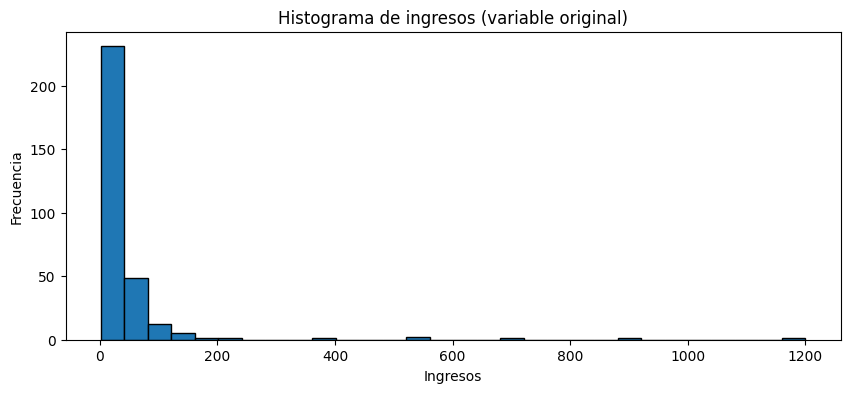

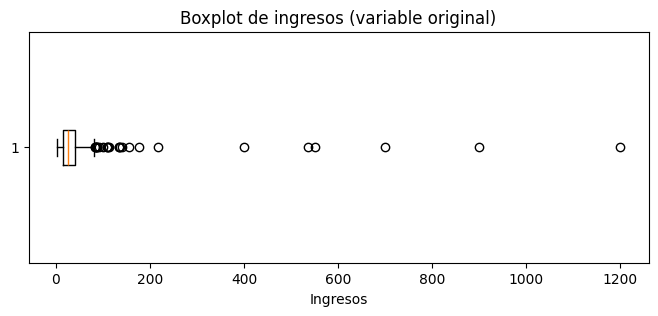

In [ ]:
# ==========================================
# GRÁFICOS DE LA VARIABLE ORIGINAL
# ==========================================

plt.figure(figsize=(10, 4))
plt.hist(df["ingresos"], bins=30, edgecolor="black")
plt.title("Histograma de ingresos (variable original)")
plt.xlabel("Ingresos")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(8, 3))
plt.boxplot(df["ingresos"], vert=False)
plt.title("Boxplot de ingresos (variable original)")
plt.xlabel("Ingresos")
plt.show()

## Interpretación de la variable original

Si la distribución está muy cargada hacia la derecha, significa que:
- la mayoría de los datos se concentra en valores bajos o medios,
- pero unos pocos valores grandes estiran la distribución.

En estos casos, el promedio suele quedar más influido por los valores extremos, por lo que también conviene revisar la mediana y el IQR.

In [ ]:
# ==========================================
# MEDIANA, CUARTILES E IQR
# ==========================================
# Estas medidas son robustas frente a valores extremos.

mediana = df["ingresos"].median()
q1 = df["ingresos"].quantile(0.25)
q3 = df["ingresos"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print("Mediana:", round(mediana, 2))
print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Límite inferior:", round(limite_inferior, 2))
print("Límite superior:", round(limite_superior, 2))

Mediana: 25.89
Q1: 14.27
Q3: 41.31
IQR: 27.04
Límite inferior: -26.28
Límite superior: 81.86


In [ ]:
# ==========================================
# DETECTAR OUTLIERS USANDO IQR
# ==========================================
# Un valor será considerado outlier si está por debajo del límite inferior
# o por encima del límite superior.

mascara_outliers = (df["ingresos"] < limite_inferior) | (df["ingresos"] > limite_superior)

outliers = df[mascara_outliers]

print("Cantidad de outliers detectados:", outliers.shape[0])
print("\nPrimeros outliers encontrados:\n")
print(outliers.head(10))

Cantidad de outliers detectados: 25

Primeros outliers encontrados:

       ingresos
3     82.965419
6     86.779486
31   107.966668
71    83.967452
73    85.773914
106  110.935474
113  176.019307
125  141.509167
135   84.770493
156  109.138706


## ¿Por qué usar mediana e IQR?

Cuando existen valores extremos:
- el **promedio** puede subir mucho,
- pero la **mediana** suele mantenerse más estable.

Por eso:
- el promedio representa mejor el "centro" cuando la distribución es simétrica,
- la mediana representa mejor el "centro" cuando hay asimetría u outliers.

El IQR, además, permite detectar observaciones atípicas de una forma simple y muy usada en análisis exploratorio.

In [ ]:
# ==========================================
# COMPARAR PROMEDIO VS MEDIANA
# ==========================================

promedio = df["ingresos"].mean()

print("Promedio:", round(promedio, 2))
print("Mediana:", round(mediana, 2))

# Si el promedio es bastante mayor que la mediana,
# eso suele ser una señal de asimetría positiva.

Promedio: 45.88
Mediana: 25.89


## Parte C: transformación logarítmica

Ahora aplicaremos una transformación logarítmica.

Usaremos:

log(ingresos + 1)

Se suma 1 para evitar problemas si existiera algún valor igual a 0.

### ¿Qué esperamos?
- que la distribución quede menos sesgada,
- que los valores extremos pierdan peso relativo,
- que el histograma se vea más equilibrado.

In [ ]:
# ==========================================
# APLICAR TRANSFORMACIÓN LOGARÍTMICA
# ==========================================
# np.log1p(x) equivale a log(x + 1)

df["ingresos_log"] = np.log1p(df["ingresos"])

print("Primeras filas con la nueva variable transformada:\n")
print(df.head())

Primeras filas con la nueva variable transformada:

    ingresos  ingresos_log
0  36.502156      3.624398
1  21.963644      3.133912
2  41.188160      3.742140
3  82.965419      4.430405
4  20.341788      3.060667


In [ ]:
# ==========================================
# ESTADÍSTICAS DE LA VARIABLE TRANSFORMADA
# ==========================================

print("Estadísticas descriptivas de la variable transformada:\n")
print(df["ingresos_log"].describe())

print("\nAsimetría (skewness) después de la transformación logarítmica:")
print(round(skew(df["ingresos_log"]), 3))

Estadísticas descriptivas de la variable transformada:

count    305.000000
mean       3.302535
std        0.854687
min        1.042004
25%        2.726173
50%        3.291914
75%        3.745032
max        7.090910
Name: ingresos_log, dtype: float64

Asimetría (skewness) después de la transformación logarítmica:
0.998


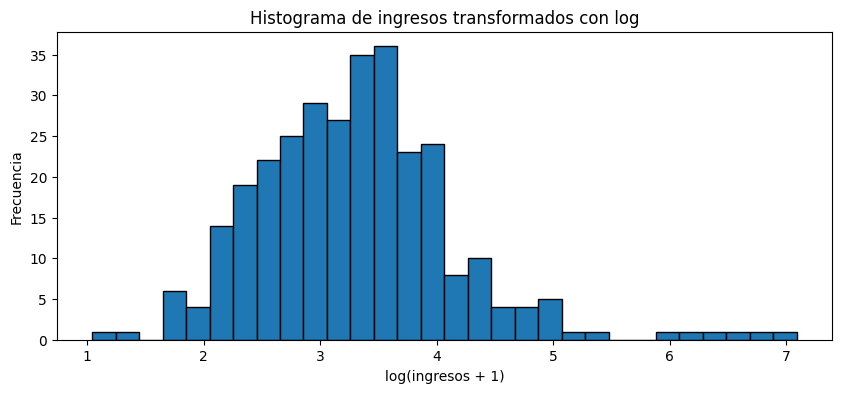

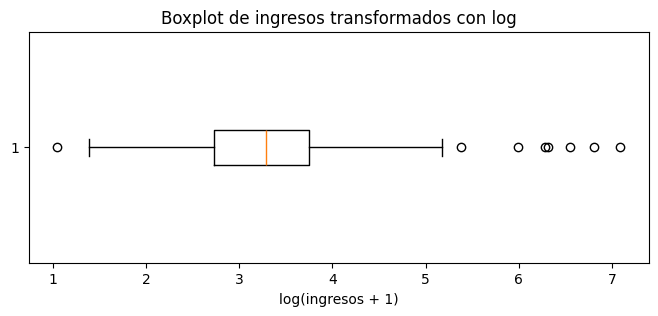

In [ ]:
# ==========================================
# GRÁFICOS DESPUÉS DE LA TRANSFORMACIÓN
# ==========================================

plt.figure(figsize=(10, 4))
plt.hist(df["ingresos_log"], bins=30, edgecolor="black")
plt.title("Histograma de ingresos transformados con log")
plt.xlabel("log(ingresos + 1)")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(8, 3))
plt.boxplot(df["ingresos_log"], vert=False)
plt.title("Boxplot de ingresos transformados con log")
plt.xlabel("log(ingresos + 1)")
plt.show()

## Interpretación de la transformación logarítmica

Si la transformación funcionó bien, deberíamos observar:
- menor asimetría,
- menor separación entre la mayoría de los casos y los valores extremos,
- una distribución más compacta y manejable.

Esto no significa "eliminar mágicamente" los outliers, sino reducir su influencia relativa.

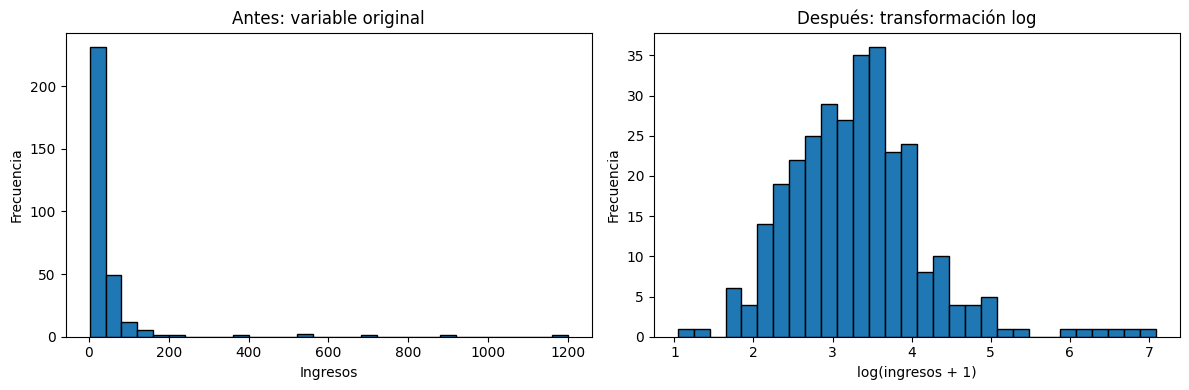

In [ ]:
# ==========================================
# COMPARACIÓN VISUAL: ANTES Y DESPUÉS
# ==========================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df["ingresos"], bins=30, edgecolor="black")
plt.title("Antes: variable original")
plt.xlabel("Ingresos")
plt.ylabel("Frecuencia")

plt.subplot(1, 2, 2)
plt.hist(df["ingresos_log"], bins=30, edgecolor="black")
plt.title("Después: transformación log")
plt.xlabel("log(ingresos + 1)")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## Parte D: relación entre variables categóricas con chi-cuadrado

Ahora cambiaremos de tema.

Vamos a crear dos variables categóricas:
- `metodo_estudio`: Individual o Grupal
- `resultado`: Aprueba o Reprueba

Luego construiremos una tabla de contingencia y aplicaremos la prueba de chi-cuadrado para determinar si ambas variables parecen estar asociadas.

In [ ]:
# ==========================================
# CREAR UN EJEMPLO CATEGÓRICO
# ==========================================
# Generaremos una tabla simple de estudiantes con método de estudio y resultado.

datos_categoricos = pd.DataFrame({
    "metodo_estudio": (
        ["Individual"] * 60 +
        ["Grupal"] * 60
    ),
    "resultado": (
        ["Aprueba"] * 42 + ["Reprueba"] * 18 +   # Individual
        ["Aprueba"] * 28 + ["Reprueba"] * 32     # Grupal
    )
})

datos_categoricos.head()

,metodo_estudio,resultado
0,Individual,Aprueba
1,Individual,Aprueba
2,Individual,Aprueba
3,Individual,Aprueba
4,Individual,Aprueba


In [ ]:
# ==========================================
# TABLA DE CONTINGENCIA
# ==========================================
# La tabla de contingencia resume cuántos casos hay en cada combinación de categorías.

tabla_contingencia = pd.crosstab(
    datos_categoricos["metodo_estudio"],
    datos_categoricos["resultado"]
)

print("Tabla de contingencia:\n")
print(tabla_contingencia)

Tabla de contingencia:

resultado       Aprueba  Reprueba
metodo_estudio                   
Grupal               28        32
Individual           42        18


## ¿Qué hace chi-cuadrado?

La prueba compara:
- las frecuencias observadas en la tabla,
- con las frecuencias esperadas si no hubiera relación entre las variables.

Si las diferencias entre observadas y esperadas son grandes, el estadístico chi-cuadrado aumenta.

### Regla general
- Si valor-p < 0.05: hay evidencia de asociación.
- Si valor-p >= 0.05: no hay evidencia suficiente de asociación.

In [ ]:
# ==========================================
# PRUEBA DE CHI-CUADRADO
# ==========================================

chi2, p_valor, grados_libertad, frecuencias_esperadas = chi2_contingency(tabla_contingencia)

print("Estadístico chi-cuadrado:", round(chi2, 4))
print("Valor-p:", round(p_valor, 6))
print("Grados de libertad:", grados_libertad)

print("\nFrecuencias esperadas si no hubiera asociación:\n")
print(pd.DataFrame(
    frecuencias_esperadas,
    index=tabla_contingencia.index,
    columns=tabla_contingencia.columns
).round(2))

Estadístico chi-cuadrado: 5.7943
Valor-p: 0.016078
Grados de libertad: 1

Frecuencias esperadas si no hubiera asociación:

resultado       Aprueba  Reprueba
metodo_estudio                   
Grupal             35.0      25.0
Individual         35.0      25.0


Nota: En una tabla de contingencia, los grados de libertad indican cuántas celdas pueden variar libremente una vez fijados los totales por fila y columna.
En chi-cuadrado se calculan como: (número de filas - 1) × (número de columnas - 1).

In [ ]:
# ==========================================
# INTERPRETACIÓN AUTOMÁTICA DEL RESULTADO
# ==========================================

alpha = 0.05

print("Hipótesis nula (H0): las variables son independientes.")
print("Hipótesis alternativa (H1): las variables están asociadas.\n")

if p_valor < alpha:
    print("Conclusión: Se rechaza H0.")
    print("Hay evidencia estadística de asociación entre método de estudio y resultado.")
else:
    print("Conclusión: No se rechaza H0.")
    print("No hay evidencia suficiente para afirmar asociación entre las variables.")

Hipótesis nula (H0): las variables son independientes.
Hipótesis alternativa (H1): las variables están asociadas.

Conclusión: Se rechaza H0.
Hay evidencia estadística de asociación entre método de estudio y resultado.


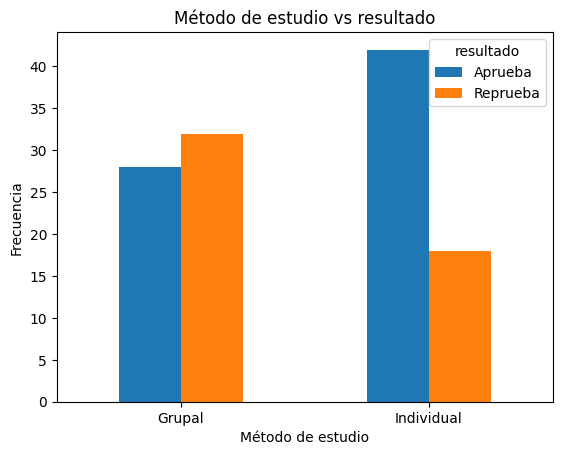

In [ ]:
# ==========================================
# VISUALIZACIÓN DE LA TABLA DE CONTINGENCIA
# ==========================================
# Graficamos la frecuencia de cada resultado según método de estudio.

tabla_contingencia.plot(kind="bar")
plt.title("Método de estudio vs resultado")
plt.xlabel("Método de estudio")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

# Conclusiones finales

## Sobre la transformación logarítmica
La transformación logarítmica es útil cuando una variable numérica:
- tiene asimetría positiva,
- contiene valores extremos grandes,
- y necesita una escala más estable para el análisis.

## Sobre la mediana e IQR
La mediana y el IQR son medidas robustas:
- la mediana representa mejor el centro cuando hay outliers,
- el IQR permite detectar valores atípicos mediante límites simples.

## Sobre chi-cuadrado
La prueba de chi-cuadrado se usa para estudiar relaciones entre variables categóricas.
No trabaja con promedios, sino con frecuencias observadas y esperadas.

En resumen:
- **logaritmo**: transforma variables numéricas sesgadas,
- **mediana e IQR**: resumen y detectan outliers en variables numéricas,
- **chi-cuadrado**: analiza asociación entre variables categóricas.